# Ruleset Generation Pipeline — Step-by-Step Tutorial

This notebook walks through the entire ruleset generation pipeline, from evidence collection to final output.

**What you'll learn:**
1. How to set up the environment (data downloads + Gemini API key)
2. How evidence is collected from 10 biomedical databases (by category)
3. How the 3-stage LLM pipeline synthesizes a simulation ruleset
4. How programmatic overrides and validation correct LLM hallucinations
5. How to visualize and interpret the final output

**Prerequisites:**
- Python 3.10+
- A Gemini API key ([get one free](https://aistudio.google.com/apikey))
- Optional: run `bash setup.sh` to download local data files (~3.5 GB) for improved accuracy

**Runtime:** ~3-5 minutes per drug (most time spent on LLM calls)

---
## 0. Environment Setup

Before running the pipeline, you need:
1. **The project files** — the notebook auto-detects the project root (checks current directory, `./ruleset_generation/`, and Kaggle input paths)
2. **Gemini API key** — free at https://aistudio.google.com/apikey (store as Kaggle Secret `GEMINI_API_KEY` or set `RULE_ENGINE_LLM_API_KEY` env var)
3. (Optional) Run `setup.sh` to download local data files for improved accuracy

In [1]:
import os, sys, warnings, pathlib
warnings.filterwarnings("ignore", message=".*pickleshare.*")

# Auto-detect project root (works on Kaggle, Colab, and local machines)
_candidates = [
    pathlib.Path.cwd(),                                     # Running from project root
    pathlib.Path.cwd() / "ruleset_generation",              # Subdirectory
    pathlib.Path("/kaggle/input/ruleset-generation"),        # Kaggle dataset
]

# Also search sibling directories (notebook lives alongside project dir)
_candidates += sorted(pathlib.Path.cwd().glob("*/rule_engine/.."), key=lambda p: p.name)
_candidates += sorted(pathlib.Path.cwd().glob("*/*/rule_engine/.."), key=lambda p: p.name)

if os.environ.get("RULESET_GEN_ROOT"):
    _candidates.insert(0, pathlib.Path(os.environ["RULESET_GEN_ROOT"]))

PROJECT_DIR = next((p.resolve() for p in _candidates if (p / "rule_engine").is_dir()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Cannot find project root (expected 'rule_engine/' directory). "
        "Set RULESET_GEN_ROOT env var or run from the project directory."
    )

os.chdir(PROJECT_DIR)
print(f"Project directory: {PROJECT_DIR.name}/")

Project directory: rule_discovery/


In [2]:
# Install dependencies (run once)
!pip install -q -r requirements.txt matplotlib seaborn nest_asyncio


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import sys, os, json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from IPython.display import display, HTML, Markdown

# Prevent event-loop conflicts when mixing async libraries in Jupyter
import nest_asyncio
nest_asyncio.apply()

# Ensure rule_engine is importable
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT.name}/")
print(f"Python: {sys.version.split()[0]}")

Project root: rule_discovery/
Python: 3.10.12


### Download Data Files (optional — skip if you want)

The pipeline can run with just the 6 **API sources** (DailyMed, CT.gov, OpenFDA, PubChem, ChEMBL, PubMed) and no local data. However, downloading the 3 local databases improves accuracy by adding OnSIDES ADE validation, PrimeKG knowledge graph context, and DrugBank pharmacology data.

Run `setup.sh` to download and process them automatically:

| Dataset | Size | What It Provides |
|---------|------|------------------|
| **PrimeKG** | ~925 MB | Knowledge graph — drug-disease, drug-gene relationships |
| **DrugBank** | ~170 MB | Drug-target binding, pharmacological properties |
| **OnSIDES** | ~2 GB | 7.1M validated drug-ADE pairs from 51,460 FDA labels |

**Skip this cell** if you don't need local data or have already run `setup.sh`.

In [4]:
# Download local databases (PrimeKG, DrugBank, OnSIDES) — skips if already present
# These 3 databases add ~3.5 GB of evidence data that dramatically improves results
!bash setup.sh 2>&1 | grep -E '^\[|^=|Done|passed|Complete|Next|Skipped|already|error|Error' | head -30

[1/6] Virtual environment already exists: venv/
[2/6] Installing Python dependencies...
    Done.
[3/6] PrimeKG already processed:
[4/6] DrugBank CSVs already exist.
      Augmented KG edges already exist.
[5/6] OnSIDES database already exists: data/onsides/onsides.db
[--] PDS: Skipped (no credentials).
[6/6] Running healthcheck...
All checks passed!
    Healthcheck passed.
  Setup Complete
Next steps:


### Gemini API Key (Required)

The pipeline uses **Gemini 2.0 Flash** via OpenAI-compatible endpoint.  
Get a free API key at https://aistudio.google.com/apikey

**On Kaggle:** Store your key as a Kaggle Secret named `GEMINI_API_KEY`.  
**Locally:** Set the `RULE_ENGINE_LLM_API_KEY` environment variable, or you will be prompted to enter it.

In [5]:
import os

# Load API key: Kaggle Secrets > environment variable > interactive prompt
try:
    from kaggle_secrets import UserSecretsClient
    os.environ["RULE_ENGINE_LLM_API_KEY"] = UserSecretsClient().get_secret("GEMINI_API_KEY")
    print("Gemini API key loaded from Kaggle Secrets.")
except (ImportError, Exception):
    if "RULE_ENGINE_LLM_API_KEY" not in os.environ:
        import getpass
        os.environ["RULE_ENGINE_LLM_API_KEY"] = getpass.getpass("Enter your Gemini API key: ")
    print("Gemini API key loaded from environment.")

Gemini API key loaded from environment.


### Define Drug + Indication

We'll use **Paclitaxel + Carboplatin** for Non-Small Cell Lung Cancer as the example — both drugs have structured DailyMed AE tables and rich evidence across all 10 sources. You can change `DRUGS` and `INDICATION` below to generate rulesets for any drug-indication pair.

In [6]:
# Change these to generate rulesets for different drugs
DRUGS = ["Paclitaxel", "Carboplatin"]
INDICATION = "Non-Small Cell Lung Cancer"

DRUG_LABEL = "+".join(DRUGS).lower()
INDICATION_LABEL = INDICATION.lower().replace(" ", "_")
OUTPUT_SUBDIR = f"{DRUG_LABEL}_{INDICATION_LABEL}"

print(f"Drug(s):     {' + '.join(DRUGS)}")
print(f"Indication:  {INDICATION}")
print(f"Output dir:  output/{OUTPUT_SUBDIR}/")

Drug(s):     Paclitaxel + Carboplatin
Indication:  Non-Small Cell Lung Cancer
Output dir:  output/paclitaxel+carboplatin_non-small_cell_lung_cancer/


In [7]:
from rule_engine.config import RuleEngineConfig

config = RuleEngineConfig()

print(f"LLM Model:    {config.llm_model}")
print(f"Rate Limit:   {config.rate_limit_rpm} RPM")
print(f"OnSIDES DB:   {'exists' if config.onsides_db.exists() else 'MISSING'}")
print(f"PrimeKG:      {'exists' if config.primekg_nodes.exists() else 'MISSING'}")
print(f"PDS data:     {'exists' if config.pds_data_dir.exists() else 'not downloaded'}")

LLM Model:    gemini-2.0-flash


Rate Limit:   150 RPM
OnSIDES DB:   exists
PrimeKG:      exists


PDS data:     exists


---
## 1. Evidence Collection

The pipeline queries **10 databases** in parallel, organized into 3 categories:

| Category | Sources | Access |
|----------|---------|--------|
| **API** (6) | DailyMed, ClinicalTrials.gov, OpenFDA, PubChem, ChEMBL, PubMed | Public, no credentials |
| **Local DB** (3) | PrimeKG, DrugBank, OnSIDES | Downloaded by `setup.sh` |
| **Remote** (1) | Project Data Sphere | PDS account required |

### 1a. API Sources (6 databases, no credentials needed)

These query public REST APIs in real time.

In [8]:
from rule_engine.evidence.dailymed import fetch_dailymed
from rule_engine.evidence.clinical_trials import fetch_clinical_trials, fetch_clinical_trials_combo
from rule_engine.evidence.openfda import fetch_openfda_aes
from rule_engine.evidence.pubchem import fetch_pubchem
from rule_engine.evidence.chembl import fetch_chembl
from rule_engine.evidence.literature import fetch_literature

print("All API evidence modules loaded.")

All API evidence modules loaded.


#### DailyMed — FDA-Approved Drug Labels

DailyMed provides the **official FDA label** for each drug, including dosage, boxed warnings, and (when available) structured AE incidence tables with grade 3-4 breakdowns.

**Note:** Older drugs like Cisplatin and Etoposide have their adverse reactions as narrative text rather than structured tables. When DailyMed lacks a structured AE table, the pipeline falls back to **ClinicalTrials.gov reported AEs** for frequency data.

In [9]:
# DailyMed — FDA-approved drug labels (AE incidence tables, dosage, boxed warnings)
dm_results = {}
for drug in DRUGS:
    dm = await fetch_dailymed(drug)
    dm_results[drug] = dm
    boxed = ", has boxed warning" if dm.boxed_warning else ""
    if not dm.found:
        print(f"  DailyMed [{drug}]: NOT FOUND")
    elif dm.ae_table:
        print(f"  DailyMed [{drug}]: {len(dm.ae_table)} AEs in structured table{boxed}")
    else:
        print(f"  DailyMed [{drug}]: Label found (narrative format, no structured AE table){boxed}")
        print(f"    → AE frequencies will come from ClinicalTrials.gov instead")

# Show sample AE table if available
for drug, dm in dm_results.items():
    if dm.ae_table:
        print(f"\n  Sample AEs from {drug} DailyMed label:")
        for ae in dm.ae_table[:5]:
            print(f"    {ae['term']:30s}  {ae['incidence_pct']:5.1f}%  (grade 3-4: {ae.get('grade34_pct', 'N/A')}%)")

  DailyMed [Paclitaxel]: 9 AEs in structured table, has boxed warning


  DailyMed [Carboplatin]: 36 AEs in structured table, has boxed warning

  Sample AEs from Paclitaxel DailyMed label:
    •  Alopecia                      87.0%  (grade 3-4: N/A%)
    •  Injection Site Reaction       13.0%  (grade 3-4: N/A%)
    •  Hypersensitivity Reaction f    1.0%  (grade 3-4: N/A%)
    •  Cardio vascular Events         1.0%  (grade 3-4: N/A%)
    •  Neuromotor Toxicity            1.0%  (grade 3-4: N/A%)

  Sample AEs from Carboplatin DailyMed label:
    Nausea and vomiting              93.0%  (grade 3-4: 98.0%)
    Vomiting                         84.0%  (grade 3-4: 97.0%)
    Other GI adverse reactions       50.0%  (grade 3-4: 62.0%)
    Mucositis                        10.0%  (grade 3-4: 9.0%)
    Alopecia                         50.0%  (grade 3-4: 62.0%)


#### ClinicalTrials.gov — Trial Demographics & Endpoints

ClinicalTrials.gov provides trial-level data: how many trials exist, what phase they reached, baseline demographics (age, sex), and reported AEs. For combination therapy, a dedicated combo search finds trials that used the exact drug combination.

In [10]:
# ClinicalTrials.gov — trial demographics, endpoints, reported AEs
ct_results = {}
for drug in DRUGS:
    ct = await fetch_clinical_trials(drug, INDICATION)
    ct_results[drug] = ct
    print(f"  CT.gov [{drug}]: {ct.trial_count} trials, max phase {ct.max_phase}, "
          f"{len(ct.reported_aes)} reported AEs")

# Combo trial search (for combination therapy)
if len(DRUGS) > 1:
    combo_ct = await fetch_clinical_trials_combo(DRUGS, INDICATION)
    print(f"  CT.gov [combo]: {combo_ct.trial_count} trials")
    if combo_ct.baseline_demographics:
        bd = combo_ct.baseline_demographics
        print(f"    Demographics: age={bd.get('age_mean', '?')} +/- {bd.get('age_std', '?')}, "
              f"male={bd.get('sex_male', '?')}, female={bd.get('sex_female', '?')}")

  CT.gov [Paclitaxel]: 50 trials, max phase 3, 146 reported AEs


  CT.gov [Carboplatin]: 50 trials, max phase 3, 115 reported AEs


  CT.gov [combo]: 50 trials
    Demographics: age=? +/- ?, male=213, female=124


#### OpenFDA/FAERS — Post-Market Adverse Event Reports

The FDA Adverse Event Reporting System (FAERS) contains real-world AE reports submitted after drug approval. Useful for rare AEs not captured in clinical trials and for time-to-onset data.

In [11]:
# OpenFDA/FAERS — post-market adverse event reports
fda_results = {}
for drug in DRUGS:
    fda = await fetch_openfda_aes(drug)
    fda_results[drug] = fda
    print(f"  OpenFDA [{drug}]: {fda.total_ae_reports} reports, "
          f"{len(fda.top_adverse_events)} top AEs, "
          f"timing data: {'Yes' if fda.has_timing_data else 'No'}")

  OpenFDA [Paclitaxel]: 164826 reports, 100 top AEs, timing data: Yes


  OpenFDA [Carboplatin]: 214227 reports, 100 top AEs, timing data: Yes


#### PubChem, ChEMBL & PubMed — Molecular Properties, Bioactivity & Literature

These three sources provide complementary chemical and literature context:
- **PubChem**: Molecular weight, logP, Lipinski violations (drug-likeness)
- **ChEMBL**: Mechanism of action, bioactivity data, max clinical phase
- **PubMed**: Literature co-occurrence score (how often drug + indication appear together)

In [12]:
# PubChem, ChEMBL, PubMed — molecular properties, bioactivity, literature
for drug in DRUGS:
    pc = await fetch_pubchem(drug)
    ch = await fetch_chembl(drug)
    lit = await fetch_literature(drug, INDICATION)
    print(f"  {drug}:")
    print(f"    PubChem: MW={pc.molecular_weight}, logP={pc.logp}, Lipinski violations={pc.lipinski_violations}")
    print(f"    ChEMBL:  MoA='{ch.mechanism_of_action or 'N/A'}', phase={ch.max_phase}")
    print(f"    PubMed:  {lit.article_count} articles, co-occurrence score={lit.cooccurrence_score:.2f}")

  Paclitaxel:
    PubChem: MW=853.9, logP=2.5, Lipinski violations=2
    ChEMBL:  MoA='Tubulin inhibitor', phase=4
    PubMed:  3091 articles, co-occurrence score=1.00


  Carboplatin:
    PubChem: MW=371.25, logP=None, Lipinski violations=0
    ChEMBL:  MoA='DNA inhibitor', phase=4
    PubMed:  3015 articles, co-occurrence score=1.00


#### Visualize: AE Frequencies per Drug

The chart below shows the **top 15 AEs by incidence** from each drug's FDA label (DailyMed). For older drugs like Cisplatin and Etoposide whose labels use narrative text instead of structured tables, the pipeline falls back to **ClinicalTrials.gov reported AEs**.

**What to look for:**
- **Red bars (>30%)**: Very common AEs — these should definitely appear in the final ruleset
- **Orange bars (10-30%)**: Common AEs — most will be retained after pruning
- **Blue bars (<10%)**: Less common — may be pruned if not corroborated by other sources

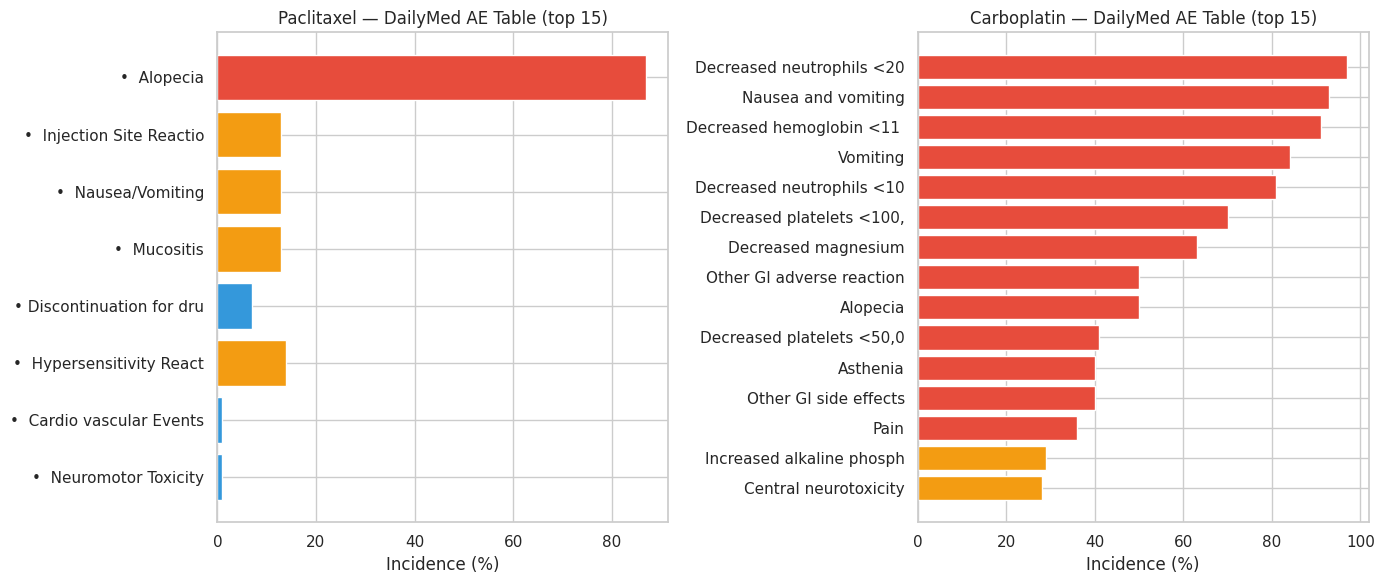

In [13]:
# Plot AE frequencies for each drug
# Uses DailyMed AE table when available; falls back to ClinicalTrials.gov reported AEs
fig, axes = plt.subplots(1, len(DRUGS), figsize=(7 * len(DRUGS), 6), squeeze=False)

for idx, (drug, dm) in enumerate(dm_results.items()):
    ax = axes[0][idx]
    if dm.ae_table:
        # DailyMed structured table available
        top = sorted(dm.ae_table, key=lambda x: x["incidence_pct"], reverse=True)[:15]
        terms = [ae["term"][:25] for ae in top]
        freqs = [ae["incidence_pct"] for ae in top]
        source_label = "DailyMed AE Table"
    elif drug in ct_results and ct_results[drug].reported_aes:
        # Fallback: use ClinicalTrials.gov reported AEs
        ct_aes = ct_results[drug].reported_aes
        # CT.gov reported_aes are dicts with term + stats
        scored = []
        for ae in ct_aes:
            if isinstance(ae, dict) and ae.get("pct") is not None:
                scored.append(ae)
            elif isinstance(ae, dict) and ae.get("count") is not None and ae.get("at_risk"):
                ae["pct"] = 100.0 * ae["count"] / ae["at_risk"]
                scored.append(ae)
        scored = sorted(scored, key=lambda x: x.get("pct", 0), reverse=True)[:15]
        terms = [ae.get("term", ae.get("ae_term", "?"))[:25] for ae in scored]
        freqs = [ae.get("pct", 0) for ae in scored]
        source_label = "ClinicalTrials.gov Reported AEs"
    else:
        ax.text(0.5, 0.5, "No AE frequency data", ha="center", va="center", fontsize=14)
        ax.set_title(drug)
        continue

    colors = ["#e74c3c" if f > 30 else "#f39c12" if f > 10 else "#3498db" for f in freqs]
    ax.barh(terms[::-1], freqs[::-1], color=colors[::-1])
    ax.set_xlabel("Incidence (%)")
    ax.set_title(f"{drug} — {source_label} (top 15)")

plt.tight_layout()
plt.show()

### 1b. Local Database Sources (3 databases)

These read from files downloaded by `setup.sh`. No internet needed.

In [14]:
from rule_engine.evidence.local_dbs import fetch_drugbank, fetch_primekg
from rule_engine.evidence.onsides import fetch_onsides

for drug in DRUGS:
    # DrugBank — drug-target binding, pharmacology
    db = await fetch_drugbank(drug, config)
    print(f"  DrugBank [{drug}]: found={db.found}, targets={len(db.targets)}, DDIs={db.ddi_count}")
    if db.moa:
        print(f"    MoA: {db.moa[:100]}...")

    # PrimeKG — knowledge graph (drug-disease, drug-gene)
    kg = await fetch_primekg(drug, INDICATION, config)
    print(f"  PrimeKG  [{drug}]: found={kg.found}, diseases={len(kg.disease_associations)}, "
          f"genes={len(kg.gene_targets)}")

    # OnSIDES — 7.1M validated drug-ADE pairs from FDA labels
    ons = await fetch_onsides(drug, config)
    print(f"  OnSIDES  [{drug}]: found={ons.found}, {ons.total_pairs} ADE pairs, "
          f"boxed warnings={len(ons.boxed_warning_aes)}")
    if ons.boxed_warning_aes:
        print(f"    Boxed warnings: {', '.join(ons.boxed_warning_aes[:5])}")
    print()

  DrugBank [Paclitaxel]: found=True, targets=18, DDIs=2878


  PrimeKG  [Paclitaxel]: found=True, diseases=110, genes=18
  OnSIDES  [Paclitaxel]: found=True, 279 ADE pairs, boxed warnings=1
    Boxed warnings: Kaposi's sarcoma



  DrugBank [Carboplatin]: found=True, targets=15, DDIs=2242


  PrimeKG  [Carboplatin]: found=True, diseases=78, genes=15
  OnSIDES  [Carboplatin]: found=True, 129 ADE pairs, boxed warnings=1
    Boxed warnings: Vomiting



#### Visualize: OnSIDES ADE Pair Prediction Scores

OnSIDES uses a PubMedBERT model to extract drug-ADE pairs from FDA labels with confidence scores. Higher prediction scores indicate stronger evidence for the association.

**What to look for:**
- **Red bars**: Boxed warning AEs — these are injected into the final ruleset if missing
- **Score > 0.8**: High-confidence associations that corroborate DailyMed data
- Compare with DailyMed: AEs appearing in both sources have stronger evidence

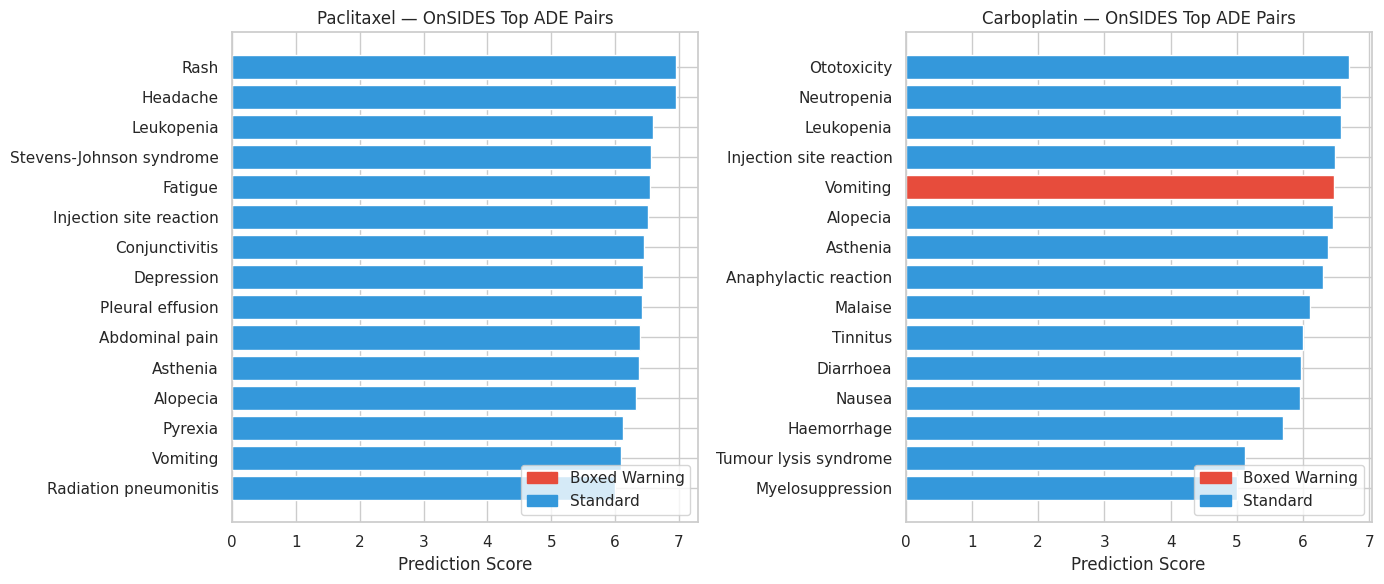

In [15]:
# OnSIDES top ADE pairs by prediction score
fig, axes = plt.subplots(1, len(DRUGS), figsize=(7 * len(DRUGS), 6), squeeze=False)

for idx, drug in enumerate(DRUGS):
    ax = axes[0][idx]
    ons = await fetch_onsides(drug, config)
    if ons.ae_pairs:
        # Filter out pairs with None scores before sorting
        scored_pairs = [p for p in ons.ae_pairs if p.get("mean_pred_score") is not None]
        top = sorted(scored_pairs, key=lambda x: x["mean_pred_score"], reverse=True)[:15]
        terms = [p["pt_meddra_term"][:25] for p in top]
        scores = [p["mean_pred_score"] for p in top]
        colors = ["#e74c3c" if p.get("is_boxed_warning") else "#3498db" for p in top]
        ax.barh(terms[::-1], scores[::-1], color=colors[::-1])
        ax.set_xlabel("Prediction Score")
        ax.set_title(f"{drug} — OnSIDES Top ADE Pairs")
        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color="#e74c3c", label="Boxed Warning"),
                           Patch(color="#3498db", label="Standard")], loc="lower right")
    else:
        ax.text(0.5, 0.5, "No OnSIDES data", ha="center", va="center", fontsize=14)
        ax.set_title(drug)

plt.tight_layout()
plt.show()

### 1c. Remote Source — Project Data Sphere (optional)

PDS provides **patient-level** data from real clinical trials.  
Requires a free account at https://projectdatasphere.org

If PDS data is cached locally (from a previous `setup.sh` run), it will be used even without live credentials.

In [16]:
from rule_engine.evidence.projectdatasphere import fetch_pds

pds = await fetch_pds(DRUGS, INDICATION, config)

if pds.found:
    t = pds.matched_trial
    d = pds.demographics
    print(f"  PDS match: trial={t.trial_id}, n={t.n_patients}, score={t.match_score:.2f}")
    print(f"  Demographics: n={d.n_patients}, age={d.age_mean:.1f} +/- {d.age_std:.1f}, "
          f"male={d.pct_male:.1f}%, female={d.pct_female:.1f}%")
    print(f"  AEs: {len(pds.ae_aggregates)} unique terms")
    print(f"  Efficacy: ORR={pds.efficacy.overall_response_rate_pct}%")
    print(f"  Regimen: {len(pds.regimen)} drugs")
    for r in pds.regimen:
        print(f"    {r.drug}: {r.median_dose} {r.dose_unit} ({r.route})")
else:
    print("  PDS: No matching trial found (or data not downloaded).")
    print("  The pipeline will use the other 9 sources.")

  PDS: No matching trial found (or data not downloaded).
  The pipeline will use the other 9 sources.


#### Visualize: PDS Demographics (if available)

If PDS matched a trial, these charts show the **real patient-level distributions** — far more accurate than aggregate summaries from ClinicalTrials.gov. PDS demographics always override CT.gov when available.

**What to look for:**
- **Age**: Is the distribution skewed? Oncology trials typically center around 60-65 years
- **Sex**: Many lung cancer trials skew male (60-70%)
- **ECOG**: Most trials enroll ECOG 0-1; ECOG 2+ patients are often excluded

In [17]:
if pds.found and pds.demographics.n_patients > 0:
    d = pds.demographics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Age distribution (simulated from mean/std)
    ax = axes[0]
    ages = np.random.normal(d.age_mean, d.age_std, 1000)
    ages = ages[(ages >= 18) & (ages <= 95)]
    ax.hist(ages, bins=25, color="#3498db", edgecolor="white")
    ax.axvline(d.age_mean, color="red", linestyle="--", label=f"Mean={d.age_mean:.1f}")
    ax.set_xlabel("Age")
    ax.set_title(f"PDS Age Distribution (n={d.n_patients})")
    ax.legend()

    # Sex
    ax = axes[1]
    ax.pie([d.pct_male, d.pct_female], labels=["Male", "Female"],
           autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
    ax.set_title("Sex Distribution")

    # ECOG
    ax = axes[2]
    if d.ecog_distribution:
        ecog_labels = [f"ECOG {k}" for k in sorted(d.ecog_distribution.keys())]
        ecog_vals = [d.ecog_distribution[k] for k in sorted(d.ecog_distribution.keys())]
        ax.bar(ecog_labels, ecog_vals, color="#2ecc71")
        ax.set_ylabel("Proportion")
        ax.set_title("ECOG Performance Status")
    else:
        ax.text(0.5, 0.5, "No ECOG data", ha="center", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("PDS data not available — skipping visualization.")

PDS data not available — skipping visualization.


### Evidence Summary

In [18]:
# Collect all evidence via the orchestrator (same as pipeline does internally)
from rule_engine.evidence.collector import collect_evidence
import logging

# Suppress API retry noise (PubMed/ChEMBL rate-limits on repeated runs)
for logger_name in ["rule_engine", "httpx", "httpcore"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

print("Collecting all evidence via orchestrator (parallel)...")
bundle = await collect_evidence(DRUGS, INDICATION, config)
print("Done!\n")

# Restore logging
logging.getLogger("rule_engine").setLevel(logging.WARNING)

# Summary table
rows = []
for drug in DRUGS:
    d = bundle.per_drug.get(drug)
    if d:
        dm_count = len(d.dailymed.ae_table) if d.dailymed.found else 0
        dm_label = f"{dm_count:3d} AEs" if dm_count > 0 else "narrative"
        rows.append({
            "Drug": drug,
            "DailyMed": dm_label,
            "OpenFDA Reports": d.openfda.total_ae_reports,
            "OnSIDES Pairs": d.onsides.total_pairs,
            "ChEMBL Activities": d.chembl.activity_count,
            "DrugBank Targets": len(d.drugbank.targets),
        })

ct = bundle.clinical_trials
print("Per-Drug Evidence:")
for r in rows:
    print(f"  {r['Drug']:20s}  DailyMed={r['DailyMed']:>9s}  OpenFDA={r['OpenFDA Reports']:6d} reports  "
          f"OnSIDES={r['OnSIDES Pairs']:4d} pairs  ChEMBL={r['ChEMBL Activities']:3d}  DrugBank={r['DrugBank Targets']:2d} targets")

print(f"\nShared Evidence:")
print(f"  ClinicalTrials.gov: {ct.trial_count} trials, {len(ct.reported_aes)} reported AEs")
print(f"  Combo trials:       {bundle.combo_trials.trial_count} trials")
print(f"  PrimeKG:            {bundle.primekg.found}")
print(f"  PDS:                {'matched' if bundle.pds.found else 'no match'}")

Done!

Per-Drug Evidence:
  Paclitaxel            DailyMed=    9 AEs  OpenFDA=164826 reports  OnSIDES= 279 pairs  ChEMBL=12819  DrugBank=18 targets
  Carboplatin           DailyMed=   36 AEs  OpenFDA=214227 reports  OnSIDES= 129 pairs  ChEMBL=2677  DrugBank=15 targets

Shared Evidence:
  ClinicalTrials.gov: 100 trials, 146 reported AEs
  Combo trials:       50 trials
  PrimeKG:            True
  PDS:                no match


---
## 2. Run the Full Pipeline

Now we run the complete multi-stage LLM pipeline:  
**Stage 1** (5 parallel extractions) → **Stage 2** (grounding) → **Stage 3** (synthesis) → **Overrides** → **Validation** → **Output**

This takes ~2-3 minutes per attempt and makes 7-12 LLM calls. The pipeline retries up to 3 times if Gemini produces unparseable JSON (non-deterministic failure).

**What to expect:**
- Progress messages as each stage completes
- Stage 2 may report a JSON parse failure — this is normal (programmatic overrides compensate)
- The pipeline auto-corrects hallucination patterns and writes split output (`base.json` + type overlay)
- If all 3 attempts fail, the notebook falls back to pre-generated output for visualization

In [19]:
from rule_engine.pipeline import run_pipeline
import time, logging

# Enable multi-stage mode (3-stage LLM pipeline with programmatic overrides)
config.multi_stage = True

# Suppress noisy stderr from API retries during pipeline execution
logging.getLogger("rule_engine").setLevel(logging.ERROR)
logging.getLogger("httpx").setLevel(logging.ERROR)

print(f"Running pipeline for {' + '.join(DRUGS)} / {INDICATION}...")
print(f"This will make 7-12 LLM calls to {config.llm_model}.\n")

# Retry up to 3 times — Gemini occasionally produces unparseable JSON
MAX_RETRIES = 3
start = time.time()

for attempt in range(1, MAX_RETRIES + 1):
    if attempt > 1:
        print(f"\n--- Retry {attempt}/{MAX_RETRIES} (LLM JSON parse failures are non-deterministic) ---\n")
    result = await run_pipeline([(DRUGS, INDICATION)], config)
    if result.successful:
        break

elapsed = time.time() - start
logging.getLogger("rule_engine").setLevel(logging.WARNING)

print(f"\nPipeline completed in {elapsed:.1f}s ({attempt} attempt{'s' if attempt > 1 else ''})")
print(f"  Successful: {len(result.successful)}")
print(f"  Failed:     {len(result.failed)}")

if result.successful:
    drugs, indication, output_path = result.successful[0]
    drugs_key = "+".join(drugs)
    print(f"  Output:     {output_path.name}/")
    warnings_list = result.warnings.get(drugs_key, [])
    print(f"  Warnings:   {len(warnings_list)}")
elif result.failed:
    print(f"\nPipeline failed after {MAX_RETRIES} attempts. Using pre-generated output for visualization.")

Running pipeline for Paclitaxel + Carboplatin / Non-Small Cell Lung Cancer...
This will make 7-12 LLM calls to gemini-2.0-flash.



Aggressive repair also failed: Expecting ',' delimiter: line 911 column 8 (char 21032)


Pipeline failed for Paclitaxel + Carboplatin / Non-Small Cell Lung Cancer: Expecting ',' delimiter: line 911 column 8 (char 21032)



--- Retry 2/3 (LLM JSON parse failures are non-deterministic) ---



Aggressive repair also failed: Expecting ',' delimiter: line 894 column 8 (char 20653)


Pipeline failed for Paclitaxel + Carboplatin / Non-Small Cell Lung Cancer: Expecting ',' delimiter: line 894 column 8 (char 20653)



--- Retry 3/3 (LLM JSON parse failures are non-deterministic) ---




Pipeline completed in 516.5s (3 attempts)
  Successful: 1
  Failed:     0
  Output:     paclitaxel+carboplatin_non-small_cell_lung_cancer/
  Warnings:   10


---
## 3. Inspect the Agent Log (Stage by Stage)

The pipeline records every step in an agent log JSON file. This is invaluable for debugging — it shows exactly which LLM calls were made, what evidence was used, which overrides fired, and what corrections the validator applied.

**What to look for:**
- Which Stage 1 sub-calls succeeded vs. failed (severity extraction typically fails)
- How many AE frequency corrections were applied (evidence vs. LLM values)
- How many AEs were pruned for lacking evidence
- Which LLM re-prompts were triggered (indicates missing data)

In [20]:
# Load agent log (pipeline writes to rule_sets/, pre-generated output is in output/)
log_path = None
for search_dir in [config.output_dir, PROJECT_ROOT / "output"]:
    candidate = search_dir / f"{OUTPUT_SUBDIR}_agent_log.json"
    if candidate.exists():
        log_path = candidate
        break
    # Fallback: glob for drug name
    candidates = list(search_dir.glob(f"*{DRUGS[0].lower()}*agent_log.json"))
    if candidates:
        log_path = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]
        break

if log_path is None:
    print("Agent log not found.")
    agent_log = None
else:
    agent_log = json.loads(log_path.read_text())

    print(f"Agent log: {log_path.name}")
    print(f"Model:     {agent_log['model']}")
    print(f"Timestamp: {agent_log['timestamp']}")
    print(f"Warnings:  {len(agent_log['warnings'])}")
    print(f"Stages:    {len(agent_log['stage_logs'])}")
    print()

    # Show all stages
    print("Pipeline stages executed:")
    print("-" * 60)
    for i, sl in enumerate(agent_log["stage_logs"]):
        stage = sl.get("stage", "unknown")
        if "error" in sl:
            print(f"  {i:2d}. {stage:40s}  ERROR")
        elif "prompt_len" in sl:
            print(f"  {i:2d}. {stage:40s}  LLM call (prompt={sl['prompt_len']:,} chars, response={sl['response_len']:,} chars)")
        elif "corrections" in sl:
            print(f"  {i:2d}. {stage:40s}  {len(sl['corrections'])} corrections")
        elif "pruned" in sl:
            print(f"  {i:2d}. {stage:40s}  pruned={sl['pruned']}, merged={sl['merged']}, remaining={sl['remaining']}")
        else:
            print(f"  {i:2d}. {stage:40s}  {list(sl.keys())}")

Agent log: paclitaxel+carboplatin_non-small_cell_lung_cancer_agent_log.json
Model:     gemini-2.0-flash
Timestamp: 2026-02-23T16:26:09.817900+00:00
Warnings:  10
Stages:    14

Pipeline stages executed:
------------------------------------------------------------
   0. stage1_ae_freq                            LLM call (prompt=1,745 chars, response=10,199 chars)
   1. stage1_severity                           LLM call (prompt=1,745 chars, response=7,777 chars)
   2. stage1_onset                              LLM call (prompt=1,745 chars, response=2,894 chars)
   3. stage1_triggers                           LLM call (prompt=1,745 chars, response=2,485 chars)
   4. stage1_demographics                       LLM call (prompt=1,745 chars, response=2,041 chars)
   5. stage2_grounding                          ['stage', 'response_len', 'reasoning_len']
   6. stage2_grounding                          ERROR
   7. stage3_synthesis                          ['stage', 'response_len', 'reasoning_len']

### Stage 1 Results: LLM Extraction

In [21]:
# Stage 1 sub-calls
if agent_log:
    stage1_names = ["stage1_ae_freq", "stage1_severity", "stage1_onset", "stage1_triggers", "stage1_demographics"]
    stage1_logs = [sl for sl in agent_log["stage_logs"] if sl.get("stage") in stage1_names]

    if stage1_logs:
        print("Stage 1 — Parallel LLM Extraction (5 calls):")
        print("-" * 60)
        for sl in stage1_logs:
            name = sl["stage"].replace("stage1_", "")
            print(f"  {name:15s}  prompt={sl.get('prompt_len', 0):>6,} chars  "
                  f"response={sl.get('response_len', 0):>6,} chars")
    else:
        print("Stage 1 — Single-shot mode (no per-stage breakdown)")
        print(f"  Evidence prompt: {len(agent_log.get('evidence_prompt', '')):,} chars")
        print(f"  LLM response:    {len(agent_log.get('raw_response', '')):,} chars")
else:
    print("Agent log not available — skipping Stage 1 details.")

Stage 1 — Parallel LLM Extraction (5 calls):
------------------------------------------------------------
  ae_freq          prompt= 1,745 chars  response=10,199 chars
  severity         prompt= 1,745 chars  response= 7,777 chars
  onset            prompt= 1,745 chars  response= 2,894 chars
  triggers         prompt= 1,745 chars  response= 2,485 chars
  demographics     prompt= 1,745 chars  response= 2,041 chars


### Programmatic Overrides

In [22]:
if agent_log:
    printed_something = False

    # Dose override
    dose_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "programmatic_dose_override"), None)
    if dose_log and "structured_doses" in dose_log:
        print("Dose Override (evidence-based):")
        for drug, info in dose_log["structured_doses"].items():
            print(f"  {drug}: {info.get('dose_value', 'N/A')} ({info.get('dose_unit', '')}) via {info.get('route', '')}")
        printed_something = True

    # AE frequency corrections
    ae_freq_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "ae_frequency_correction"), None)
    if ae_freq_log and "corrections" in ae_freq_log:
        corrections = ae_freq_log["corrections"]
        print(f"\nAE Frequency Corrections: {len(corrections)} AEs adjusted")
        for c in corrections[:10]:
            print(f"  {c}")
        if len(corrections) > 10:
            print(f"  ... and {len(corrections) - 10} more")
        printed_something = True

    # AE pruning
    prune_log = next((sl for sl in agent_log["stage_logs"] if sl.get("stage") == "ae_evidence_pruning"), None)
    if prune_log:
        print(f"\nAE Pruning: {prune_log.get('pruned', 0)} removed, "
              f"{prune_log.get('merged', 0)} merged, {prune_log.get('remaining', 0)} remaining")
        printed_something = True

    if not printed_something:
        # Summarize what the agent log does contain
        n_stages = len(agent_log["stage_logs"])
        n_warnings = len(agent_log.get("warnings", []))
        print(f"Programmatic overrides: {n_stages} stages logged, {n_warnings} validation warnings")
        if n_stages == 0:
            print("  (Pipeline ran in single-shot mode — overrides are applied inline)")
        # Show any stage names that do exist
        for sl in agent_log["stage_logs"]:
            stage = sl.get("stage", "unknown")
            print(f"  Stage: {stage}")
else:
    print("Agent log not available — skipping override details.")

Dose Override (evidence-based):
  Paclitaxel: 200 mg/m^2 (mg/m^2) via IV
  Carboplatin: AUC 6 (AUC) via IV

AE Frequency Corrections: 24 AEs adjusted
  Nausea: 45.0% -> 57.0%
  Diarrhea: 30.0% -> 41.8%
  Constipation: 25.0% -> 40.5%
  Pruritus: 15.0% -> 37.5%
  Alopecia: 40.0% -> 25.0%
  Neutropenia: 60.0% -> 41.8%
  Thrombocytopenia: 45.0% -> 31.0%
  Lymphopenia: 35.0% -> 10.0%
  AST increased: 20.0% -> 8.5%
  Bilirubin increased: 10.0% -> 2.5%
  ... and 14 more

AE Pruning: 5 removed, 0 merged, 32 remaining


### Validation Warnings

In [23]:
if agent_log:
    warnings = agent_log.get("warnings", [])
    print(f"Validation produced {len(warnings)} warnings:\n")

    # Group by type
    from collections import Counter
    prefixes = [w.split(":")[0] if ":" in w else w[:40] for w in warnings]
    for prefix, count in Counter(prefixes).most_common():
        print(f"  {count:2d}x  {prefix}")
else:
    print("Agent log not available — skipping validation warnings.")

Validation produced 10 warnings:

   4x  AE name normalized
   2x  Auto-populated 4 ae_risk_modifiers for '
   1x  OnSIDES cross-check
   1x  Auto-corrected sex percentages
   1x  Auto-populated 2 ae_risk_modifiers for '
   1x  Auto-populated 6 ae_risk_modifiers for '


---
## 4. Visualize the Final Output

Load the generated `base.json` and visualize key sections.

In [24]:
# Load output (check both rule_sets/ and output/ directories)
output_dir = config.output_dir / OUTPUT_SUBDIR
if not output_dir.exists():
    output_dir = PROJECT_ROOT / "output" / OUTPUT_SUBDIR

base = json.loads((output_dir / "base.json").read_text())

# Detect schema type from overlay file
overlay_files = [f for f in output_dir.iterdir() if f.name != "base.json" and f.suffix == ".json"]
schema_type = overlay_files[0].stem if overlay_files else "unknown"

print(f"Drug:        {base['drug_name']}")
print(f"Indication:  {base['indication']}")
print(f"Schema type: {schema_type}")
print(f"Cycle:       {base['trial_design']['cycle_length_days']} days")
print(f"AE count:    {len(base['ae_profile'])}")
print(f"Sections:    {list(base.keys())}")

Drug:        Paclitaxel + Carboplatin
Indication:  Non-Small Cell Lung Cancer
Schema type: iv_combination
Cycle:       21 days
AE count:    32
Sections:    ['drug_name', 'indication', 'trial_design', 'demographics', 'comorbidities', 'disease_baseline', 'ae_profile', 'efficacy', 'lab_reference_ranges', 'administration_schedule', 'dose_modification_rules', 'supportive_care_rules', 'mortality_model', 'ecog_model', 'ae_cascade_rules', 'disposition_model']


### 4a. Demographics

The demographics section defines the simulated patient population. All values are derived from clinical trial data (CT.gov or PDS), not hardcoded defaults.

**What to look for:**
- **Age**: Should match the typical oncology trial population (~60-65 mean for lung cancer)
- **Sex**: Compare with CT.gov data from Section 1a — the pipeline uses the largest trial's demographics
- **ECOG**: Most patients should be ECOG 0-1; heavy ECOG 2+ suggests a data issue

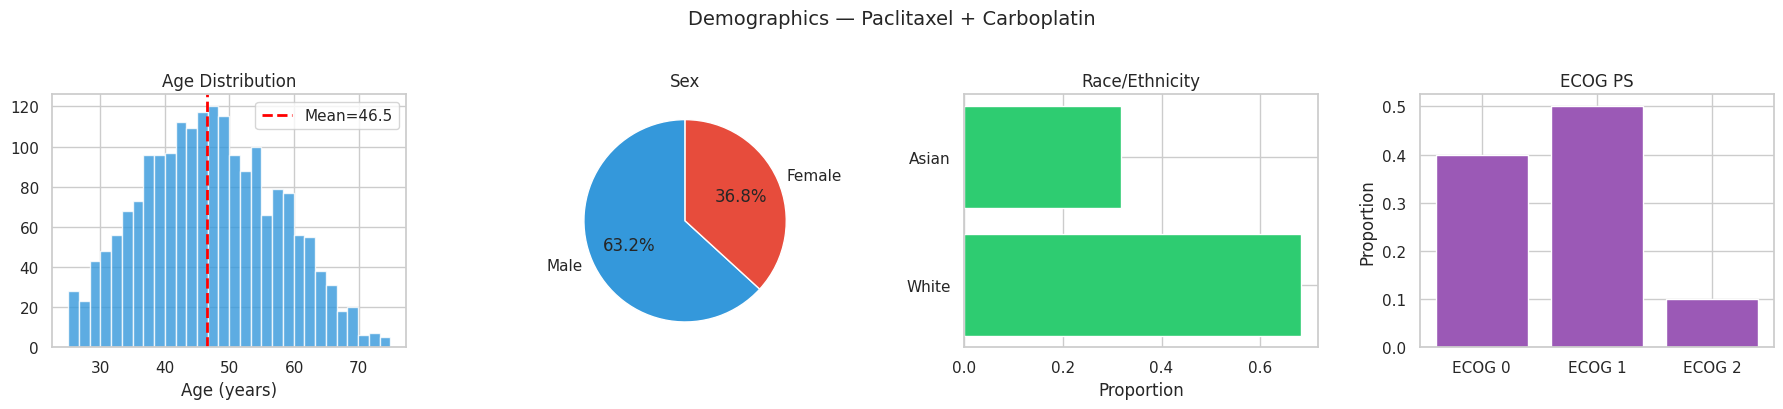

In [25]:
demo = base["demographics"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Age distribution
ax = axes[0]
age = demo["age"]["params"]
samples = np.random.normal(age["mean"], age["std"], 2000)
samples = samples[(samples >= age.get("min", 18)) & (samples <= age.get("max", 95))]
ax.hist(samples, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
ax.axvline(age["mean"], color="red", linestyle="--", linewidth=2, label=f"Mean={age['mean']:.1f}")
ax.set_xlabel("Age (years)")
ax.set_title("Age Distribution")
ax.legend()

# Sex
ax = axes[1]
sex = demo["sex"]["options"]
ax.pie(sex.values(), labels=sex.keys(), autopct="%1.1f%%",
       colors=["#3498db", "#e74c3c"], startangle=90)
ax.set_title("Sex")

# Race
ax = axes[2]
race = demo.get("race", {}).get("options", {})
if race:
    labels = [k[:15] for k in race.keys()]
    ax.barh(labels, list(race.values()), color="#2ecc71")
    ax.set_xlabel("Proportion")
ax.set_title("Race/Ethnicity")

# ECOG
ax = axes[3]
ecog = demo.get("ecog_ps", {}).get("options", {})
if ecog:
    ax.bar([f"ECOG {k}" for k in ecog.keys()], list(ecog.values()), color="#9b59b6")
    ax.set_ylabel("Proportion")
ax.set_title("ECOG PS")

plt.suptitle(f"Demographics — {base['drug_name']}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4b. Adverse Event Profile

The AE profile is the core of the ruleset — it drives the simulation's toxicity model. Each AE has an incidence (0-1), grade distribution, onset timing, and duration.

**What to look for:**
- **High-frequency AEs (>50%)**: Typically hematologic (neutropenia, anemia, thrombocytopenia) for chemo drugs
- **AE count**: Should be 15-30 for most drugs (pipeline caps at 30)
- **Compare with DailyMed chart** from Section 1a: Final frequencies should be lower (0.5x dampening applied)

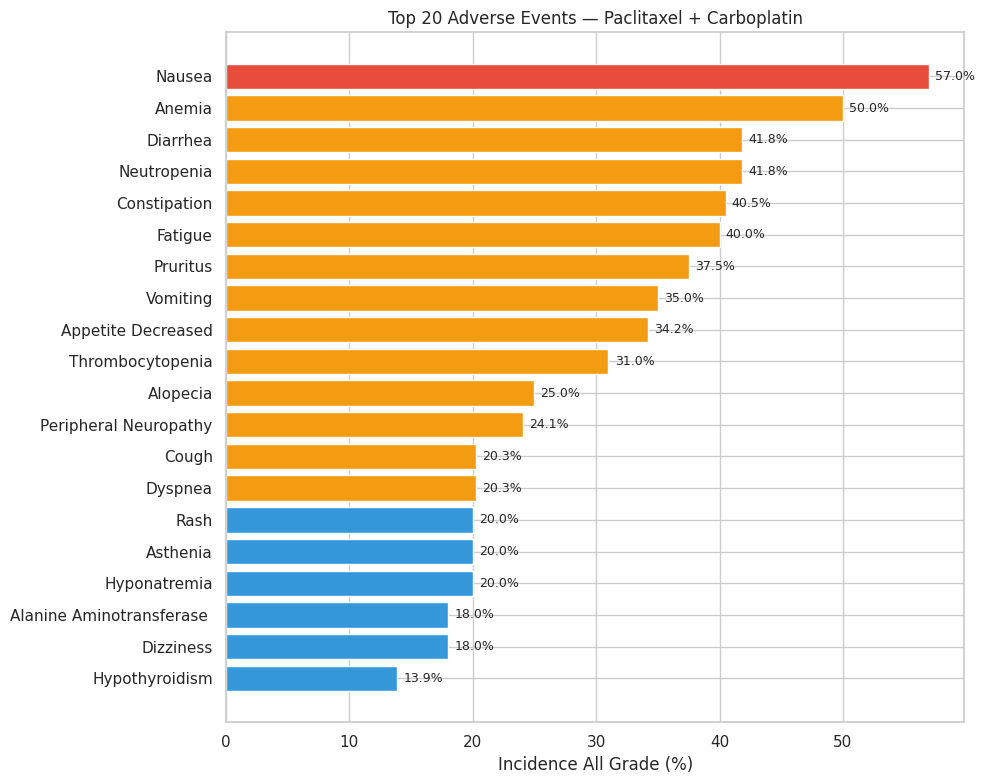

In [26]:
aes = sorted(base["ae_profile"], key=lambda x: x["incidence_all_grade"], reverse=True)

# Top 20 AEs by frequency
top_n = 20
top_aes = aes[:top_n]
terms = [ae["ae_term"].replace("_", " ").title()[:25] for ae in top_aes]
freqs = [ae["incidence_all_grade"] * 100 for ae in top_aes]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if f > 50 else "#f39c12" if f > 20 else "#3498db" for f in freqs]
bars = ax.barh(terms[::-1], freqs[::-1], color=colors[::-1])
ax.set_xlabel("Incidence All Grade (%)")
ax.set_title(f"Top {top_n} Adverse Events — {base['drug_name']}")

# Add percentage labels
for bar, val in zip(bars, freqs[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 4c. Grade Distribution (Top 10 AEs)

Each AE's severity is modeled as a grade distribution (grades 1-5), where proportions sum to ~1.0. The validator auto-corrects fabricated patterns (e.g., identical 50/30/15/5 splits across multiple AEs).

**What to look for:**
- **Hematologic AEs** (neutropenia, anemia): Should have higher grade 3-4 proportions
- **GI AEs** (nausea, vomiting): Should be mostly grade 1-2
- **Varied distributions**: If all AEs look identical, the validator's correction may not have fired — check warnings

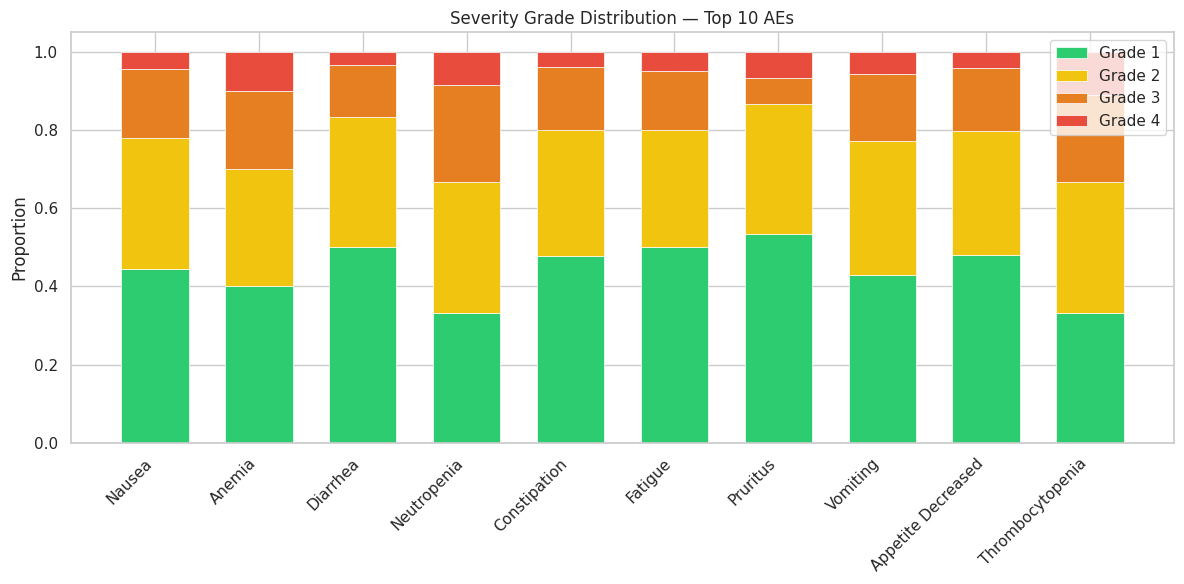

In [27]:
top_n = min(10, len(aes))
top_n_aes = aes[:top_n]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(top_n)
width = 0.65
grade_colors = {"1": "#2ecc71", "2": "#f1c40f", "3": "#e67e22", "4": "#e74c3c", "5": "#8e44ad"}

bottom = np.zeros(top_n)
for grade in ["1", "2", "3", "4", "5"]:
    vals = [ae["grade_distribution"].get(grade, 0) for ae in top_n_aes]
    if any(v > 0 for v in vals):
        ax.bar(x, vals, width, bottom=bottom, label=f"Grade {grade}",
               color=grade_colors[grade], edgecolor="white", linewidth=0.5)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([ae["ae_term"].replace("_", " ").title()[:18] for ae in top_n_aes],
                    rotation=45, ha="right")
ax.set_ylabel("Proportion")
ax.set_title(f"Severity Grade Distribution — Top {top_n} AEs")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 4d. Efficacy

Efficacy parameters include response rates (ORR, CR) and survival distributions (PFS, OS). These are extracted from CT.gov trial outcomes and override LLM estimates when available.

**What to look for:**
- **ORR**: For platinum-based SCLC regimens, expect 60-80%; for NSCLC, 30-50%
- **PFS**: Typically 4-6 months for SCLC, 4-8 months for NSCLC
- **OS**: Typically 9-12 months for SCLC, 10-16 months for NSCLC
- If PFS/OS shows "no data", the pipeline lacked CI bounds to compute distribution parameters

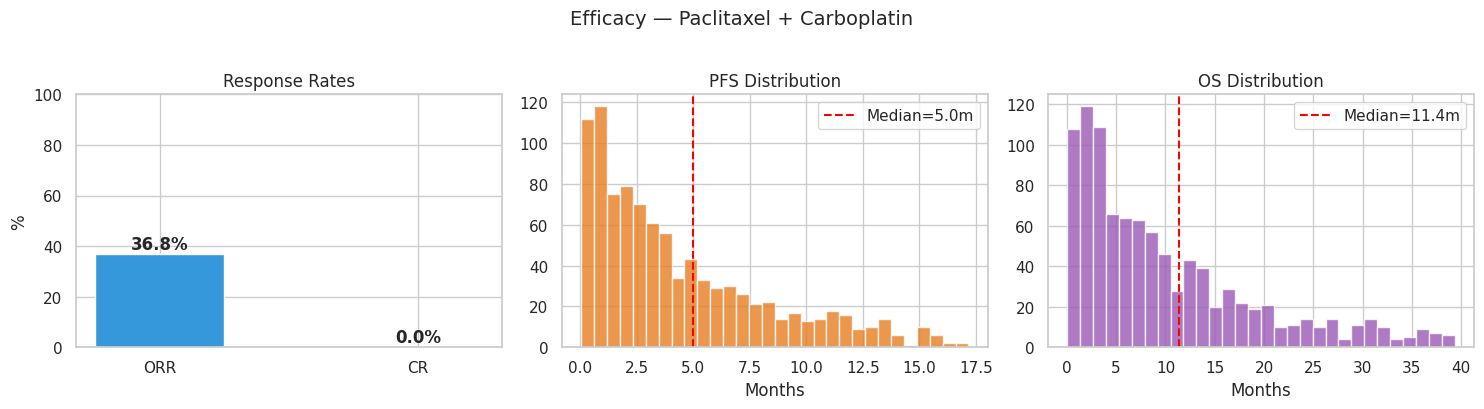

In [28]:
eff = base["efficacy"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ORR / CR
ax = axes[0]
orr = eff.get("overall_response_rate", 0) or 0
cr = eff.get("complete_response_rate", 0) or 0
ax.bar(["ORR", "CR"], [orr * 100, cr * 100], color=["#3498db", "#2ecc71"], width=0.5)
ax.set_ylabel("%")
ax.set_title("Response Rates")
ax.set_ylim(0, 100)
for i, v in enumerate([orr * 100, cr * 100]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

# PFS
ax = axes[1]
pfs = eff.get("progression_free_survival_months", {})
if pfs and pfs.get("params"):
    p = pfs["params"]
    samples = np.random.exponential(p["mean"], 1000)
    samples = samples[(samples >= p.get("min", 0)) & (samples <= p.get("max", 60))]
    ax.hist(samples, bins=30, color="#e67e22", edgecolor="white", alpha=0.8)
    ax.axvline(p["mean"], color="red", linestyle="--", label=f"Median={p['mean']:.1f}m")
    ax.legend()
ax.set_xlabel("Months")
ax.set_title("PFS Distribution")

# OS
ax = axes[2]
os_data = eff.get("overall_survival_months", {})
if os_data and os_data.get("params"):
    p = os_data["params"]
    samples = np.random.exponential(p["mean"], 1000)
    samples = samples[(samples >= p.get("min", 0)) & (samples <= p.get("max", 120))]
    ax.hist(samples, bins=30, color="#9b59b6", edgecolor="white", alpha=0.8)
    ax.axvline(p["mean"], color="red", linestyle="--", label=f"Median={p['mean']:.1f}m")
    ax.legend()
ax.set_xlabel("Months")
ax.set_title("OS Distribution")

plt.suptitle(f"Efficacy — {base['drug_name']}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4e. Administration Schedule

The dosing regimen: which drug, what dose, which route, and on which cycle days. This is one of the strongest-scoring dimensions (~97% accuracy) because doses are extracted deterministically from DailyMed labels and CT.gov descriptions.

In [29]:
admin = base["administration_schedule"]

print(f"Administration Schedule ({base['trial_design']['cycle_length_days']}-day cycle):")
print("-" * 70)
for entry in admin:
    days_str = ", ".join(str(d) for d in entry.get("cycle_days", []))
    print(f"  {entry['drug_name']:25s}  {entry['dose_per_administration']:20s}  "
          f"{entry['route']:15s}  Days: {days_str}")

Administration Schedule (21-day cycle):
----------------------------------------------------------------------
  Paclitaxel                 200 mg/m^2            INTRAVENOUS      Days: 1
  Carboplatin                AUC 6                 INTRAVENOUS      Days: 1


### 4f. Comorbidities & Dose Modification Rules

In [30]:
# Comorbidities
print("Comorbidities:")
for c in base.get("comorbidities", []):
    mods = len(c.get("conditional_modifiers", []))
    print(f"  {c['condition']:30s}  prevalence={c['base_probability']:.1%}  "
          f"modifiers={mods}")

# Dose modification rules
print(f"\nDose Modification Rules: {len(base.get('dose_modification_rules', []))}")
for rule in base.get("dose_modification_rules", [])[:5]:
    print(f"  {rule.get('ae_term', 'N/A'):25s}  {rule.get('grade_threshold', 'N/A')}  "
          f"-> {rule.get('action', 'N/A')}")

# AE cascade rules
print(f"\nAE Cascade Rules: {len(base.get('ae_cascade_rules', []))}")
for rule in base.get("ae_cascade_rules", [])[:5]:
    print(f"  {rule.get('trigger_ae', 'N/A'):25s}  -> {rule.get('resulting_ae', 'N/A'):25s}  "
          f"p={rule.get('probability', 0):.0%}")

Comorbidities:
  cardiovascular_disease          prevalence=10.0%  modifiers=4
  diabetes                        prevalence=8.0%  modifiers=2
  hypertension                    prevalence=12.0%  modifiers=4
  chronic_kidney_disease          prevalence=5.0%  modifiers=6
  peripheral_neuropathy           prevalence=7.0%  modifiers=1
  hearing_impairment              prevalence=6.0%  modifiers=0
  prior_chemotherapy              prevalence=15.0%  modifiers=0

Dose Modification Rules: 7
  nausea                     N/A  -> N/A
  anemia                     N/A  -> N/A
  neutropenia                N/A  -> N/A
  vomiting                   N/A  -> N/A
  thrombocytopenia           N/A  -> N/A

AE Cascade Rules: 0


---
## Summary

This notebook walked through the complete pipeline:

1. **Evidence Collection** — 10 databases (6 API + 3 local + 1 remote) queried in parallel
2. **Stage 1** — 5 parallel LLM calls extract AE freq, severity, onset, triggers, demographics
3. **Stage 2** — Grounding verification (gracefully degrades)
4. **Stage 3** — Final JSON synthesis with aggressive repair
5. **Overrides** — 5 deterministic evidence-based corrections
6. **Re-prompts** — Up to 5 LLM fallback calls for missing data
7. **Validation** — Auto-correction of hallucination patterns
8. **Output** — Split into `base.json` + type overlay

To generate rulesets for other drugs, change `DRUGS` and `INDICATION` in Section 0 and re-run.